In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
DATA_PATH = r"C:\Users\ASUS\Documents\New project\cars.csv"
NROWS = None

In [45]:
usecols = [
    "views", "vip", "featured", "salon", "price_x", "currency_x",
    "Marka", "Model", "Ban növü", "Rəng", "production_year",
    "img_url", "description", "extra_info", "Şəhər", "barter", "loan"
]

In [15]:
df = pd.read_csv(DATA_PATH, usecols=usecols, nrows=NROWS)

In [16]:
df.head()

,price_x,currency_x,production_year,barter,loan,salon,vip,featured,img_url,description,views,Ban növü,Marka,Model,Rəng,Şəhər,extra_info
0,15000.0,AZN,2008,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,Salam orjinal probeqdir bir ildi bizdedir biri...,492,"Hetçbek, 5 qapı",Hyundai,i30,Gümüşü,Bakı,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,23700.0,AZN,2024,NaN,NaN,Salon,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,LADA Niva Travel modelini nəğd və ya sərfəli l...,60189,"Offroader / SUV, 5 qapı",LADA (VAZ),Niva Travel,Yaşıl,Bakı,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,35600.0,$,2011,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,2473,"Offroader / SUV, 5 qapı",Toyota,Land Cruiser,Ağ,Bakı,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,26700.0,AZN,2018,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,2019 alış\n,3727,Sedan,Hyundai,Elantra,Boz,Bakı,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,10500.0,AZN,2007,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,"Maşında problem yoxdur. Motor, ABS və batareya...",446,Liftbek,Toyota,Prius,Qırmızı,Bakı,Arxa görüntü kamerası


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   price_x          653721 non-null  float64
 1   currency_x       653721 non-null  str    
 2   production_year  653721 non-null  int64  
 3   barter           225553 non-null  str    
 4   loan             163340 non-null  str    
 5   salon            193339 non-null  str    
 6   vip              288941 non-null  str    
 7   featured         163835 non-null  str    
 8   img_url          653721 non-null  str    
 9   description      638192 non-null  str    
 10  views            653721 non-null  int64  
 11  Ban növü         653721 non-null  str    
 12  Marka            653721 non-null  str    
 13  Model            653720 non-null  str    
 14  Rəng             653721 non-null  str    
 15  Şəhər            653721 non-null  str    
 16  extra_info       653721 non-null  str    
dtypes:

In [18]:
df.describe()

,price_x,production_year,views
count,653721.000000,653721.000000,653721.000000
mean,31630.966437,1995.886897,3740.731827
std,28679.360855,188.793547,10299.032842
min,500.000000,0.000000,12.000000
25%,16800.000000,2009.000000,432.000000
50%,25300.000000,2015.000000,1367.000000
75%,36800.000000,2019.000000,3412.000000
max,940000.000000,2024.000000,359317.000000


In [19]:
clean = df.copy()

clean["views"] = pd.to_numeric(clean["views"], errors="coerce")
clean["price"] = pd.to_numeric(clean["price_x"], errors="coerce")
clean["production_year"] = pd.to_numeric(clean["production_year"], errors="coerce")

clean["is_vip"] = clean["vip"].notna().astype(int)
clean["is_featured"] = clean["featured"].notna().astype(int)
clean["is_salon"] = clean["salon"].notna().astype(int)
clean["has_barter"] = clean["barter"].notna().astype(int)
clean["has_loan"] = clean["loan"].notna().astype(int)
clean["has_image"] = clean["img_url"].notna().astype(int)

clean["description"] = clean["description"].fillna("")
clean["extra_info"] = clean["extra_info"].fillna("")

clean["description_length"] = clean["description"].str.len()

clean["extra_info_count"] = np.where(
    clean["extra_info"].str.strip().eq(""),
    0,
    clean["extra_info"].str.count(r"\*") + 1
)

clean["car_age"] = 2024 - clean["production_year"]

clean.head()

,price_x,currency_x,production_year,barter,loan,salon,vip,featured,img_url,description,...,price,is_vip,is_featured,is_salon,has_barter,has_loan,has_image,description_length,extra_info_count,car_age
0,15000.0,AZN,2008,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,Salam orjinal probeqdir bir ildi bizdedir biri...,...,15000.0,0,0,0,0,0,1,258,6,16
1,23700.0,AZN,2024,NaN,NaN,Salon,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,LADA Niva Travel modelini nəğd və ya sərfəli l...,...,23700.0,1,1,1,0,0,1,108,4,0
2,35600.0,$,2011,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,...,35600.0,1,1,0,0,0,1,583,8,13
3,26700.0,AZN,2018,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,2019 alış\n,...,26700.0,1,0,0,0,0,1,10,11,6
4,10500.0,AZN,2007,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,"Maşında problem yoxdur. Motor, ABS və batareya...",...,10500.0,1,0,0,0,0,1,198,1,17


In [20]:
clean[[
    "views",
    "price",
    "currency_x",
    "production_year",
    "car_age",
    "is_vip",
    "is_featured",
    "is_salon",
    "has_barter",
    "has_loan",
    "has_image",
    "description_length",
    "extra_info_count"
]].head()

,views,price,currency_x,production_year,car_age,is_vip,is_featured,is_salon,has_barter,has_loan,has_image,description_length,extra_info_count
0,492,15000.0,AZN,2008,16,0,0,0,0,0,1,258,6
1,60189,23700.0,AZN,2024,0,1,1,1,0,0,1,108,4
2,2473,35600.0,$,2011,13,1,1,0,0,0,1,583,8
3,3727,26700.0,AZN,2018,6,1,0,0,0,0,1,10,11
4,446,10500.0,AZN,2007,17,1,0,0,0,0,1,198,1


In [21]:
final_df = clean[[
    "views",
    "price",
    "currency_x",
    "Marka",
    "Model",
    "Ban növü",
    "Rəng",
    "Şəhər",
    "production_year",
    "car_age",
    "is_vip",
    "is_featured",
    "is_salon",
    "has_barter",
    "has_loan",
    "has_image",
    "description_length",
    "extra_info_count"
]].copy()

final_df.head()

,views,price,currency_x,Marka,Model,Ban növü,Rəng,Şəhər,production_year,car_age,is_vip,is_featured,is_salon,has_barter,has_loan,has_image,description_length,extra_info_count
0,492,15000.0,AZN,Hyundai,i30,"Hetçbek, 5 qapı",Gümüşü,Bakı,2008,16,0,0,0,0,0,1,258,6
1,60189,23700.0,AZN,LADA (VAZ),Niva Travel,"Offroader / SUV, 5 qapı",Yaşıl,Bakı,2024,0,1,1,1,0,0,1,108,4
2,2473,35600.0,$,Toyota,Land Cruiser,"Offroader / SUV, 5 qapı",Ağ,Bakı,2011,13,1,1,0,0,0,1,583,8
3,3727,26700.0,AZN,Hyundai,Elantra,Sedan,Boz,Bakı,2018,6,1,0,0,0,0,1,10,11
4,446,10500.0,AZN,Toyota,Prius,Liftbek,Qırmızı,Bakı,2007,17,1,0,0,0,0,1,198,1


In [22]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   views               653721 non-null  int64  
 1   price               653721 non-null  float64
 2   currency_x          653721 non-null  str    
 3   Marka               653721 non-null  str    
 4   Model               653720 non-null  str    
 5   Ban növü            653721 non-null  str    
 6   Rəng                653721 non-null  str    
 7   Şəhər               653721 non-null  str    
 8   production_year     653721 non-null  int64  
 9   car_age             653721 non-null  int64  
 10  is_vip              653721 non-null  int64  
 11  is_featured         653721 non-null  int64  
 12  is_salon            653721 non-null  int64  
 13  has_barter          653721 non-null  int64  
 14  has_loan            653721 non-null  int64  
 15  has_image           653721 non-null  int64  


In [23]:
final_df["Model"] = final_df["Model"].fillna("Unknown")

In [24]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   views               653721 non-null  int64  
 1   price               653721 non-null  float64
 2   currency_x          653721 non-null  str    
 3   Marka               653721 non-null  str    
 4   Model               653721 non-null  str    
 5   Ban növü            653721 non-null  str    
 6   Rəng                653721 non-null  str    
 7   Şəhər               653721 non-null  str    
 8   production_year     653721 non-null  int64  
 9   car_age             653721 non-null  int64  
 10  is_vip              653721 non-null  int64  
 11  is_featured         653721 non-null  int64  
 12  is_salon            653721 non-null  int64  
 13  has_barter          653721 non-null  int64  
 14  has_loan            653721 non-null  int64  
 15  has_image           653721 non-null  int64  


In [25]:
final_df.to_csv("clean_attention_analysis.csv", index=False, encoding="utf-8-sig")

In [26]:
final_df.head()

,views,price,currency_x,Marka,Model,Ban növü,Rəng,Şəhər,production_year,car_age,is_vip,is_featured,is_salon,has_barter,has_loan,has_image,description_length,extra_info_count
0,492,15000.0,AZN,Hyundai,i30,"Hetçbek, 5 qapı",Gümüşü,Bakı,2008,16,0,0,0,0,0,1,258,6
1,60189,23700.0,AZN,LADA (VAZ),Niva Travel,"Offroader / SUV, 5 qapı",Yaşıl,Bakı,2024,0,1,1,1,0,0,1,108,4
2,2473,35600.0,$,Toyota,Land Cruiser,"Offroader / SUV, 5 qapı",Ağ,Bakı,2011,13,1,1,0,0,0,1,583,8
3,3727,26700.0,AZN,Hyundai,Elantra,Sedan,Boz,Bakı,2018,6,1,0,0,0,0,1,10,11
4,446,10500.0,AZN,Toyota,Prius,Liftbek,Qırmızı,Bakı,2007,17,1,0,0,0,0,1,198,1


In [27]:
final_df.groupby("is_vip")["views"].agg(["count", "mean", "median", "max"])

,count,mean,median,max
is_vip,,,,
0,364780,1446.666100,635.0,144934
1,288941,6636.926193,2896.0,359317


In [28]:
final_df["currency_x"].value_counts()

currency_x
AZN    465598
$      182236
€        5887
Name: count, dtype: int64

In [29]:
exchange_rates = {
    "AZN": 1,
    "$": 1.7,
    "€": 1.85
}

final_df["price_azn"] = final_df["price"] * final_df["currency_x"].map(exchange_rates)

final_df[["price", "currency_x", "price_azn"]].head(10)

,price,currency_x,price_azn
0,15000.0,AZN,15000.0
1,23700.0,AZN,23700.0
2,35600.0,$,60520.0
3,26700.0,AZN,26700.0
4,10500.0,AZN,10500.0
5,37000.0,$,62900.0
6,21800.0,AZN,21800.0
7,42500.0,AZN,42500.0
8,24500.0,AZN,24500.0
9,33500.0,AZN,33500.0


In [30]:
final_df.head()

,views,price,currency_x,Marka,Model,Ban növü,Rəng,Şəhər,production_year,car_age,is_vip,is_featured,is_salon,has_barter,has_loan,has_image,description_length,extra_info_count,price_azn
0,492,15000.0,AZN,Hyundai,i30,"Hetçbek, 5 qapı",Gümüşü,Bakı,2008,16,0,0,0,0,0,1,258,6,15000.0
1,60189,23700.0,AZN,LADA (VAZ),Niva Travel,"Offroader / SUV, 5 qapı",Yaşıl,Bakı,2024,0,1,1,1,0,0,1,108,4,23700.0
2,2473,35600.0,$,Toyota,Land Cruiser,"Offroader / SUV, 5 qapı",Ağ,Bakı,2011,13,1,1,0,0,0,1,583,8,60520.0
3,3727,26700.0,AZN,Hyundai,Elantra,Sedan,Boz,Bakı,2018,6,1,0,0,0,0,1,10,11,26700.0
4,446,10500.0,AZN,Toyota,Prius,Liftbek,Qırmızı,Bakı,2007,17,1,0,0,0,0,1,198,1,10500.0


In [31]:
final_df.to_csv("clean_attention_analysis.csv", index=False, encoding="utf-8-sig")


In [32]:
check = pd.read_csv("clean_attention_analysis.csv")
check.head()

,views,price,currency_x,Marka,Model,Ban növü,Rəng,Şəhər,production_year,car_age,is_vip,is_featured,is_salon,has_barter,has_loan,has_image,description_length,extra_info_count,price_azn
0,492,15000.0,AZN,Hyundai,i30,"Hetçbek, 5 qapı",Gümüşü,Bakı,2008,16,0,0,0,0,0,1,258,6,15000.0
1,60189,23700.0,AZN,LADA (VAZ),Niva Travel,"Offroader / SUV, 5 qapı",Yaşıl,Bakı,2024,0,1,1,1,0,0,1,108,4,23700.0
2,2473,35600.0,$,Toyota,Land Cruiser,"Offroader / SUV, 5 qapı",Ağ,Bakı,2011,13,1,1,0,0,0,1,583,8,60520.0
3,3727,26700.0,AZN,Hyundai,Elantra,Sedan,Boz,Bakı,2018,6,1,0,0,0,0,1,10,11,26700.0
4,446,10500.0,AZN,Toyota,Prius,Liftbek,Qırmızı,Bakı,2007,17,1,0,0,0,0,1,198,1,10500.0


In [33]:
check.columns

Index(['views', 'price', 'currency_x', 'Marka', 'Model', 'Ban növü', 'Rəng',
       'Şəhər', 'production_year', 'car_age', 'is_vip', 'is_featured',
       'is_salon', 'has_barter', 'has_loan', 'has_image', 'description_length',
       'extra_info_count', 'price_azn'],
      dtype='str')

In [34]:
final_df.to_csv(
    "clean_attention_analysis_powerbi.csv",
    index=False,
    encoding="utf-8-sig",
    sep=";",
    decimal=","
)

In [35]:
final_df.loc[
    ~final_df["production_year"].between(1950, 2024),
    ["production_year", "car_age"]
] = pd.NA

In [36]:
final_df.to_csv(
    "clean_attention_analysis_powerbi.csv",
    index=False,
    encoding="utf-8-sig",
    sep=";",
    decimal=","
)

In [37]:
final_df["car_age"].max()

np.float64(70.0)

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.facecolor': '#0F1117',
    'axes.facecolor': '#1A1D27',
    'axes.labelcolor': '#E0E0E0',
    'xtick.color': '#AAAAAA',
    'ytick.color': '#AAAAAA',
    'text.color': '#E0E0E0',
    'axes.titlecolor': '#FFFFFF',
    'grid.color': '#2A2D3A',
})

ACCENT, ACCENT2, ACCENT3, ACCENT4 = '#00D4FF', '#FF6B6B', '#FFD93D', '#6BCB77'
BG = '#0F1117'


views_cap = df['views'].quantile(0.99)
df['views_capped'] = df['views'].clip(upper=views_cap)

In [39]:
views_cap = final_df["views"].quantile(0.99)
final_df["views_capped"] = final_df["views"].clip(upper=views_cap)

factor_labels = {
    "is_vip": "VIP Elan",
    "is_featured": "Önə Çıxarılan",
    "is_salon": "Salondan",
    "has_barter": "Barter Var",
    "has_loan": "Kredit Var",
}

factor_data = {}

for col, label in factor_labels.items():
    factor_data[label] = {
        "Var": final_df.loc[final_df[col] == 1, "views_capped"].median(),
        "Yox": final_df.loc[final_df[col] == 0, "views_capped"].median(),
    }

fdf = pd.DataFrame(factor_data).T
fdf

,Var,Yox
VIP Elan,2896.0,635.0
Önə Çıxarılan,3753.0,939.0
Salondan,1877.0,1174.0
Barter Var,1565.0,1262.0
Kredit Var,1861.0,1218.0


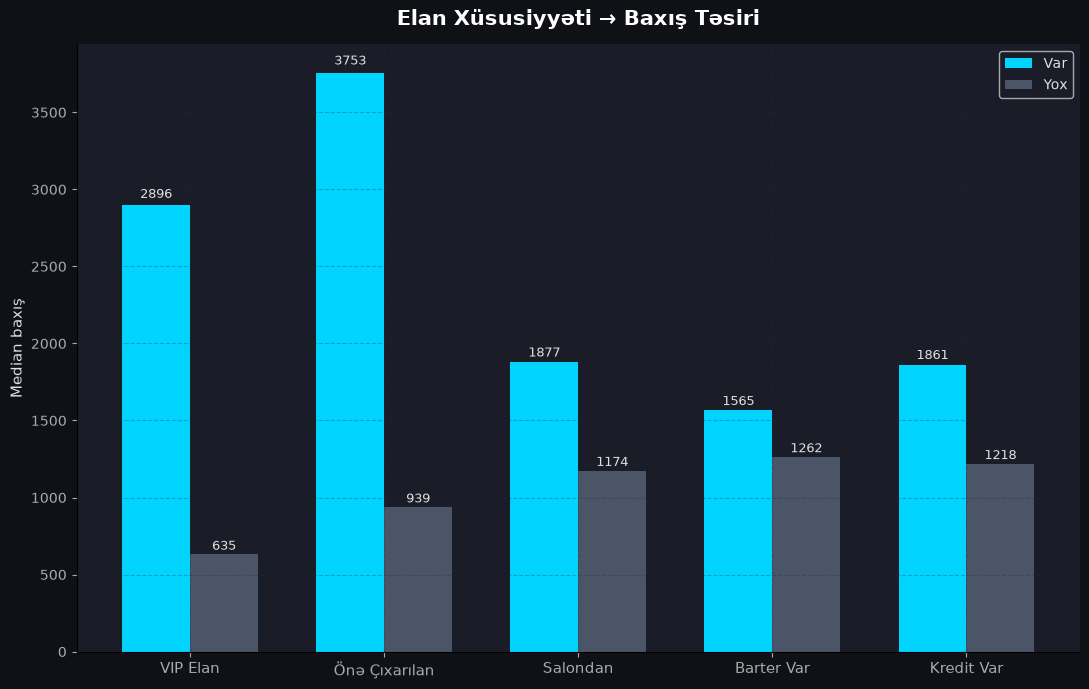

In [40]:
fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)

x = np.arange(len(fdf))
w = 0.35

b1 = ax.bar(x - w/2, fdf["Var"], width=w, color=ACCENT, label="Var", edgecolor="none")
b2 = ax.bar(x + w/2, fdf["Yox"], width=w, color="#4A5568", label="Yox", edgecolor="none")

ax.set_xticks(x)
ax.set_xticklabels(fdf.index, fontsize=11)
ax.set_ylabel("Median baxış", fontsize=11)
ax.set_title("Elan Xüsusiyyəti → Baxış Təsiri", fontsize=15, fontweight="bold", pad=14)
ax.legend(fontsize=10)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + h*0.01,
        f"{h:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

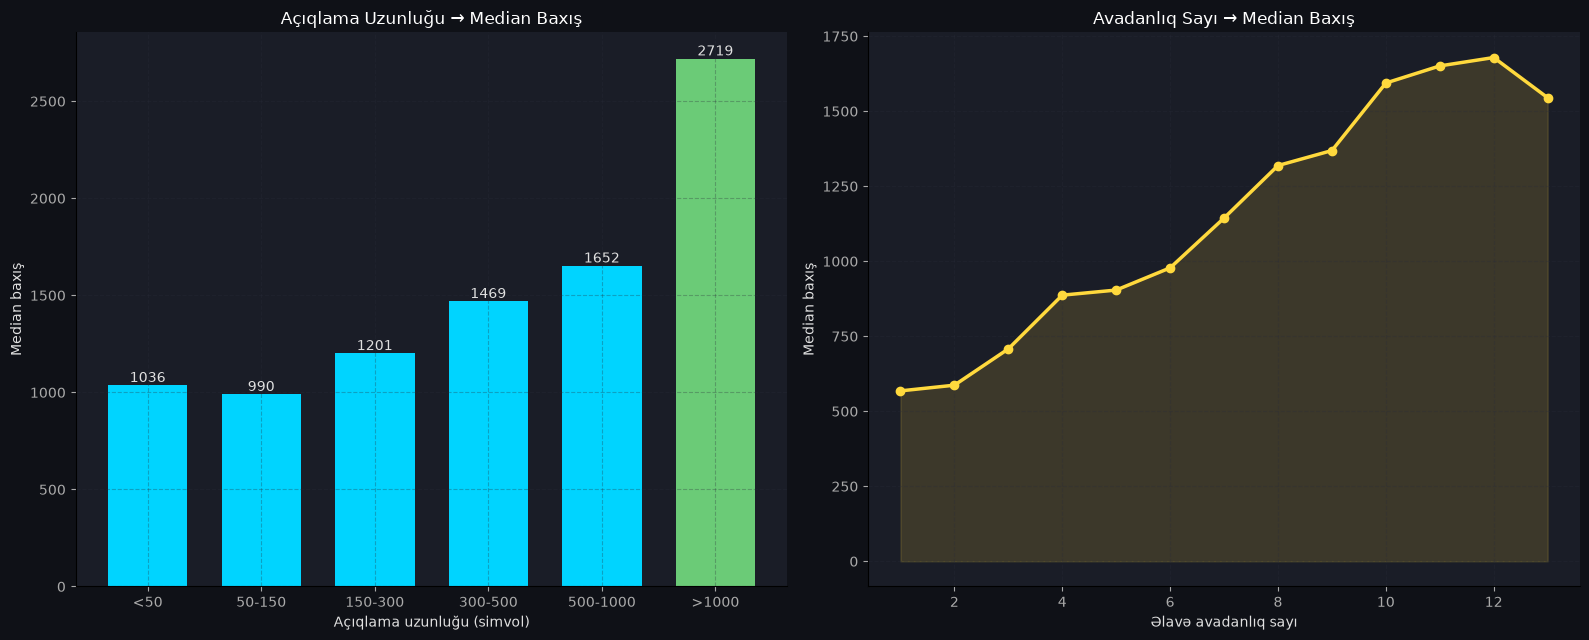

In [50]:

df = final_df.copy()


if 'views_capped' not in df.columns:
    views_cap = df['views'].quantile(0.99)
    df['views_capped'] = df['views'].clip(upper=views_cap)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), facecolor=BG)
plt.subplots_adjust(wspace=0.3)


# Açıqlama uzunluğu -> Median baxış


ax = axes[0]

desc_df = (
    df.groupby(
        pd.cut(
            df['description_length'],
            bins=[0, 50, 150, 300, 500, 1000, 99999],
            labels=['<50', '50-150', '150-300', '300-500', '500-1000', '>1000']
        ),
        observed=True
    )['views_capped']
    .median()
)

bars = ax.bar(
    desc_df.index.astype(str),
    desc_df.values,
    color=[ACCENT4 if v == desc_df.max() else ACCENT for v in desc_df.values],
    edgecolor='none',
    width=0.7
)

ax.set_xlabel('Açıqlama uzunluğu (simvol)')
ax.set_ylabel('Median baxış')
ax.set_title('Açıqlama Uzunluğu → Median Baxış')

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{h:.0f}',
        ha='center',
        va='bottom'
    )



ax2 = axes[1]

extra_df = (
    df.groupby('extra_info_count', observed=True)['views_capped']
      .median()
      .reset_index()
      .sort_values('extra_info_count')
)

ax2.plot(
    extra_df['extra_info_count'],
    extra_df['views_capped'],
    color=ACCENT3,
    linewidth=2.5,
    marker='o',
    markersize=6
)

ax2.fill_between(
    extra_df['extra_info_count'],
    extra_df['views_capped'],
    alpha=0.15,
    color=ACCENT3
)

ax2.set_xlabel('Əlavə avadanlıq sayı')
ax2.set_ylabel('Median baxış')
ax2.set_title('Avadanlıq Sayı → Median Baxış')

plt.tight_layout()
plt.show()

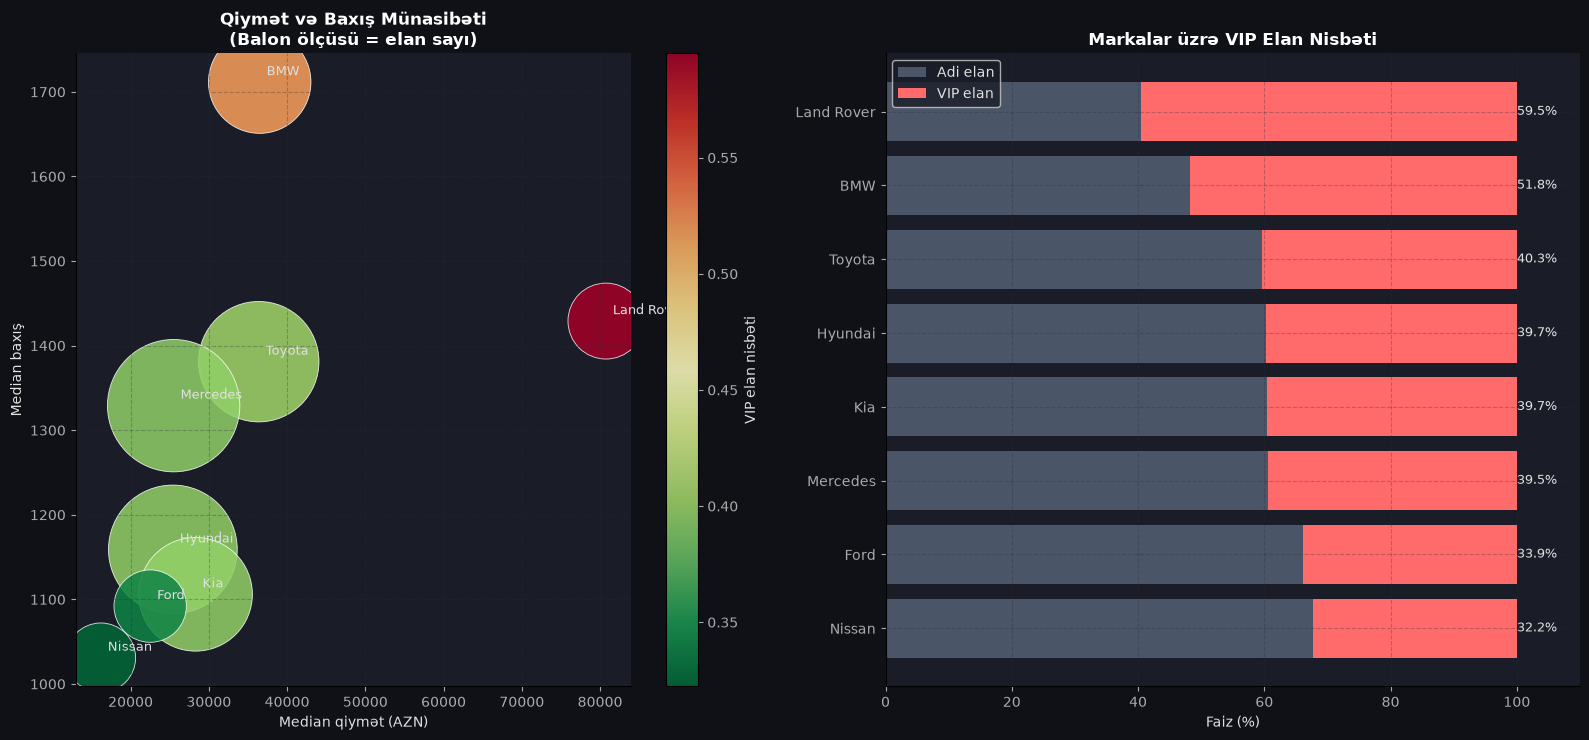

In [49]:

df = final_df.copy()

top_n = 8
min_count = 50


price_col = 'price_azn' if 'price_azn' in df.columns else 'price'

brand_counts = df['Marka'].value_counts()

valid_brands = brand_counts[brand_counts >= min_count].index

top_brands = (
    brand_counts.loc[valid_brands]
    .head(top_n)
    .index
    .tolist()
)

brand_df = (
    df[df['Marka'].isin(top_brands)]
    .groupby('Marka')
    .agg(
        med_views=('views', 'median'),
        med_price=(price_col, 'median'),
        count=('views', 'count'),
        vip_pct=('is_vip', 'mean')
    )
    .dropna()
    .sort_values('med_views', ascending=False)
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7.5),
    facecolor=BG
)

plt.subplots_adjust(wspace=0.35)


# Bubble Chart


ax = axes[0]

sc = ax.scatter(
    brand_df['med_price'],
    brand_df['med_views'],
    s=brand_df['count'] / 10,
    alpha=0.85,
    c=brand_df['vip_pct'],
    cmap='RdYlGn_r',
    edgecolors='white',
    linewidths=0.6
)

for marka, row in brand_df.iterrows():
    ax.annotate(
        marka,
        (row['med_price'], row['med_views']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('VIP elan nisbəti')

ax.set_xlabel('Median qiymət (AZN)')
ax.set_ylabel('Median baxış')
ax.set_title(
    'Qiymət və Baxış Münasibəti\n(Balon ölçüsü = elan sayı)',
    fontweight='bold'
)


# VIP Faizi


ax2 = axes[1]

brand_sorted = brand_df.sort_values('vip_pct')

non_vip = 1 - brand_sorted['vip_pct']

ax2.barh(
    brand_sorted.index,
    non_vip * 100,
    color='#4A5568',
    label='Adi elan'
)

ax2.barh(
    brand_sorted.index,
    brand_sorted['vip_pct'] * 100,
    left=non_vip * 100,
    color=ACCENT2,
    label='VIP elan'
)

for i, (marka, row) in enumerate(brand_sorted.iterrows()):
    ax2.text(
        row['vip_pct'] * 100 + (100 - row['vip_pct'] * 100),
        i,
        f"{row['vip_pct']*100:.1f}%",
        va='center',
        fontsize=9
    )

ax2.set_xlim(0, 110)
ax2.set_xlabel('Faiz (%)')
ax2.set_title(
    'Markalar üzrə VIP Elan Nisbəti',
    fontweight='bold'
)

ax2.legend()

plt.tight_layout()
plt.show()